## Uber and Lyft Cab Prices Prediction

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [4]:
ds = pd.read_csv("cab_rides.csv")
ds.sample(3)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
12786,2.66,Uber,1544990703373,Theatre District,Fenway,30.5,1.0,efca2bd2-725d-46b5-9717-8c00ff939b3c,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV
7603,3.10,Lyft,1543334601917,Northeastern University,West End,16.5,1.0,764d752a-4cd9-4ca9-99c7-16d80ca0a7b6,lyft_plus,Lyft XL
6659,5.56,Uber,1543473703945,Boston University,Financial District,14.0,1.0,b40334ba-4786-4ce2-969a-5b4989b57e87,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool


In [5]:
ds['time_stamp'] = ds['time_stamp'] // 1000

In [6]:
ds.sample(3)

,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
9687,4.72,Lyft,1543463228,Boston University,Theatre District,27.5,1.0,8d3d00d5-7e70-46b6-bb3d-aa2fce5945cf,lyft_premier,Lux
5308,4.72,Uber,1543853882,Financial District,Boston University,41.5,1.0,67fe9032-1ca3-4007-96e8-ba71eb6001cf,6d318bcc-22a3-4af6-bddd-b409bfce1546,Black SUV
8134,3.18,Lyft,1543230849,Fenway,Theatre District,11.0,1.0,2abda403-89ea-4e62-87b1-abb50f3a4869,lyft,Lyft


In [7]:
weather_ds = pd.read_csv("weather.csv")
weather_ds.sample(5)

,temp,location,clouds,pressure,rain,time_stamp,humidity,wind
2400,36.24,Haymarket Square,0.87,1018.49,NaN,1543630262,0.70,4.18
509,20.26,Back Bay,0.45,1031.72,NaN,1544701501,0.63,2.79
1963,41.04,Northeastern University,0.95,1014.18,NaN,1543218370,0.93,1.92
1825,32.74,Back Bay,0.52,1033.75,NaN,1544730302,0.57,1.80
5969,41.05,Back Bay,0.76,1028.45,NaN,1544823901,0.72,4.43


In [8]:
ds['time_stamp'] = pd.to_datetime(ds['time_stamp'], unit='s')
weather_ds['time_stamp'] = pd.to_datetime(weather_ds['time_stamp'], unit='s')

In [9]:
ds = ds.sort_values(by='time_stamp')
weather_ds = weather_ds.sort_values(by='time_stamp')

In [10]:
ds = ds.rename(columns={"source" : "location"})

In [11]:
merged_ds = pd.merge_asof(
    ds,
    weather_ds,
    on='time_stamp',
    by='location',
    tolerance=pd.Timedelta('1H'),
    direction='nearest'
)

In [12]:
merged_ds.sample(5)

,distance,cab_type,time_stamp,destination,location,price,surge_multiplier,id,product_id,name,temp,clouds,pressure,rain,humidity,wind
8620,1.73,Lyft,2018-12-02 14:08:04,North End,Theatre District,5.0,1.0,755536c6-6a6b-44ff-a60e-0e3d399821cb,lyft_line,Shared,42.77,1.00,1015.04,0.0241,0.93,7.65
13060,1.50,Lyft,2018-12-15 13:10:10,Boston University,Back Bay,13.5,1.0,2e495c54-e81c-4c5e-8661-33e121901435,lyft_plus,Lyft XL,45.44,0.95,1022.18,NaN,0.91,4.10
2753,2.15,Uber,2018-11-28 09:34:38,Back Bay,Haymarket Square,24.0,1.0,73bef059-ce70-49a4-a8d7-bc52f5f27ff6,6c84fd89-3f11-4782-9b50-97c468b19529,Black,33.34,0.41,991.80,NaN,0.84,5.98
6641,1.07,Lyft,2018-11-30 15:18:02,Northeastern University,Back Bay,13.5,1.0,18da20c8-d773-41a0-924f-6508e96d892a,lyft_premier,Lux,37.86,0.11,1017.43,NaN,0.68,2.71
7791,1.10,Uber,2018-12-01 18:07:59,Northeastern University,Back Bay,7.5,1.0,288c5f60-c61d-4b92-866a-265e2ddd009d,997acbb5-e102-41e1-b155-9df7de0a73f2,UberPool,42.43,0.49,1023.05,NaN,0.57,1.04


In [13]:
merged_ds.shape

(16405, 16)

In [14]:
merged_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16405 entries, 0 to 16404
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   distance          16405 non-null  float64       
 1   cab_type          16405 non-null  object        
 2   time_stamp        16405 non-null  datetime64[ns]
 3   destination       16405 non-null  object        
 4   location          16405 non-null  object        
 5   price             15111 non-null  float64       
 6   surge_multiplier  16405 non-null  float64       
 7   id                16405 non-null  object        
 8   product_id        16405 non-null  object        
 9   name              16405 non-null  object        
 10  temp              16405 non-null  float64       
 11  clouds            16405 non-null  float64       
 12  pressure          16405 non-null  float64       
 13  rain              2372 non-null   float64       
 14  humidity          1640

In [15]:
# Rain column must be handled first.
merged_ds['rain'].describe()

,rain
count,2372.000000
mean,0.049905
std,0.102508
min,0.000200
25%,0.004000
50%,0.013000
75%,0.039125
max,0.780700


In [16]:
import math

merged_ds['rain_category'] = merged_ds['rain'].apply(lambda x: 'No Rain' if math.isnan(x)
                                                    else ("Light Rain" if x < 0.1
                                                    else ("Moderate Rain" if x < 0.3
                                                    else "Heavy Rain" )))

In [17]:
merged_ds[['rain', 'rain_category']].sample(10)

,rain,rain_category
8257,NaN,No Rain
6929,NaN,No Rain
11056,NaN,No Rain
10527,NaN,No Rain
5230,NaN,No Rain
3009,NaN,No Rain
190,NaN,No Rain
4358,NaN,No Rain
2219,NaN,No Rain
14532,0.1547,Moderate Rain


In [18]:
merged_ds['rain_category'].value_counts()

,count
rain_category,
No Rain,14033
Light Rain,1967
Moderate Rain,365
Heavy Rain,40


<Axes: xlabel='rain_category', ylabel='count'>

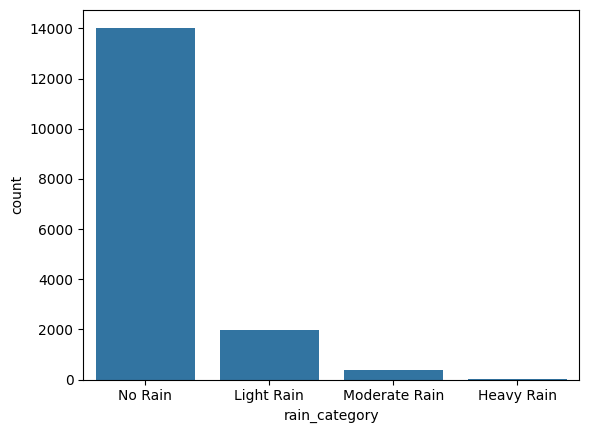

In [19]:
sns.countplot(x='rain_category', data=merged_ds)

In [20]:
merged_ds = pd.get_dummies(
    merged_ds,
    columns=['rain_category'],
)

In [21]:
merged_ds.columns

Index(['distance', 'cab_type', 'time_stamp', 'destination', 'location',
       'price', 'surge_multiplier', 'id', 'product_id', 'name', 'temp',
       'clouds', 'pressure', 'rain', 'humidity', 'wind',
       'rain_category_Heavy Rain', 'rain_category_Light Rain',
       'rain_category_Moderate Rain', 'rain_category_No Rain'],
      dtype='object')

In [22]:
merged_ds['rain'] = merged_ds['rain'].fillna(0)

In [23]:
merged_ds.isnull().sum()

,0
distance,0
cab_type,0
time_stamp,0
destination,0
location,0
price,1294
surge_multiplier,0
id,0
product_id,0
name,0


In [24]:
# Now, we need to handle 'price' column, we will simpe remove 'em all.
merged_ds = merged_ds.dropna(subset=['price'])

In [25]:
merged_ds.shape

(15111, 20)

In [26]:
merged_ds['cab_type'] = merged_ds['cab_type'].apply(lambda x: 0 if x == 'Uber' else 1)

In [27]:
# Handling Date Column
merged_ds['dayname'] = merged_ds['time_stamp'].map(lambda x: 0 if x.day_name() in ['Saturday','Sunday'] else 1)

In [28]:
# Creatung a new column 'parts_of_day' to categorize them
def categorize_time_of_day(hour):
    if 5<= hour <= 8:
        return 'Early Morning'
    elif 8< hour <= 12:
        return 'Morning'
    elif 12< hour <= 17:
        return 'Afternoon'
    elif 17< hour <= 21:
        return 'Evening'
    else:
        return 'Night'

merged_ds['day_part'] = merged_ds['time_stamp'].dt.hour.apply(categorize_time_of_day)

In [29]:
merged_ds[['time_stamp', 'dayname', 'day_part']].sample(3)

,time_stamp,dayname,day_part
8019,2018-12-01 23:13:03,0,Night
11201,2018-12-13 17:45:10,1,Afternoon
1186,2018-11-27 04:39:22,1,Night


In [30]:
merged_ds = pd.get_dummies(
    merged_ds,
    columns=['day_part']
)

In [31]:
merged_ds[['day_part_Afternoon',
       'day_part_Early Morning', 'day_part_Evening', 'day_part_Morning',
       'day_part_Night']].sample(5)

,day_part_Afternoon,day_part_Early Morning,day_part_Evening,day_part_Morning,day_part_Night
8395,False,True,False,False,False
11570,False,False,False,False,True
8227,False,False,False,False,True
13559,False,False,False,False,True
15943,False,True,False,False,False


In [32]:
# Handling Categorical Variables
print("Destination : ",merged_ds['destination'].nunique())
print("Location : ",merged_ds['location'].nunique())
print("Cab Names : ",merged_ds['name'].nunique())

Destination :  12
Location :  12
Cab Names :  12


In [33]:
merged_ds = pd.get_dummies(
    merged_ds,
    columns=['destination','location','name']
)

In [34]:
bool_cols = merged_ds.select_dtypes(include='bool').columns
merged_ds[bool_cols] = merged_ds[bool_cols].astype(int)
merged_ds.sample(1)

,distance,cab_type,time_stamp,price,surge_multiplier,id,product_id,temp,clouds,pressure,...,name_Lux,name_Lux Black,name_Lux Black XL,name_Lyft,name_Lyft XL,name_Shared,name_UberPool,name_UberX,name_UberXL,name_WAV
7901,0.72,0,2018-12-01 20:38:00,6.5,1.0,a26769e6-7ba6-4f8f-ad48-da380ada1f5b,997acbb5-e102-41e1-b155-9df7de0a73f2,40.88,0.64,1023.18,...,0,0,0,0,0,0,1,0,0,0


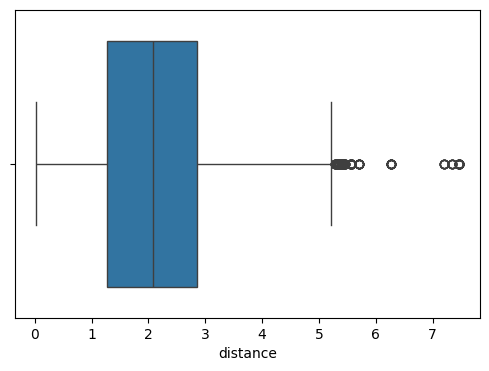

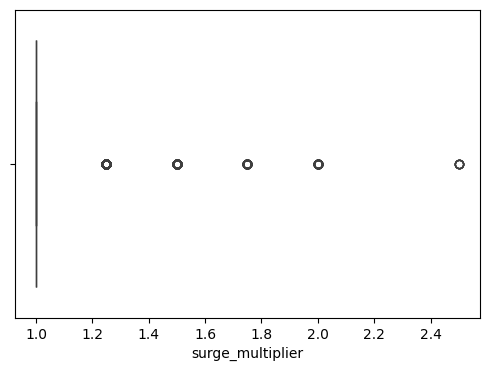

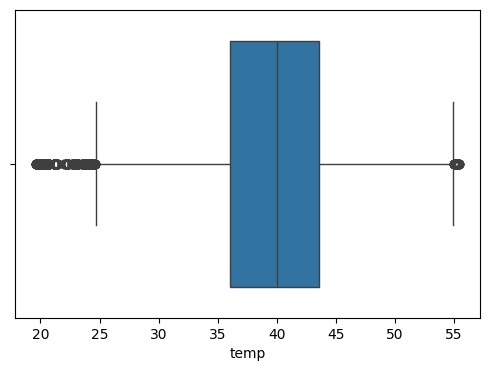

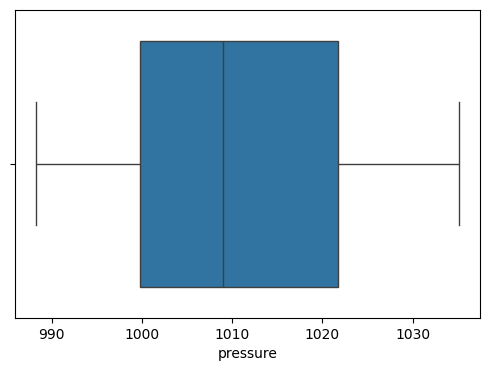

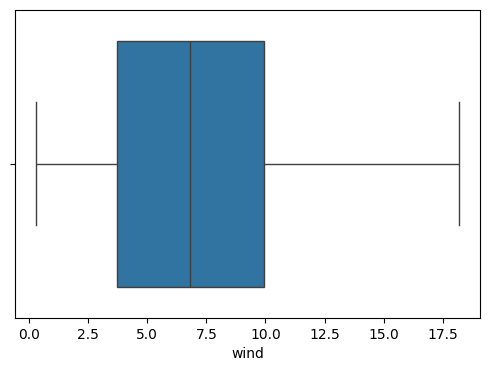

In [35]:
columns_to_scale = ['distance','surge_multiplier','temp','pressure','wind']

for cols in columns_to_scale:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = merged_ds[cols])

In [36]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
merged_ds[columns_to_scale] = scaler.fit_transform(merged_ds[columns_to_scale])


In [37]:
merged_ds = merged_ds.drop(columns=['id','product_id'])

In [38]:
# Checking Correlations of each column against target columns using 'Pearson' correlation
from scipy.stats import pearsonr

# Listing all the features to check
features_to_check = merged_ds.drop(columns=['price','time_stamp']).columns

# This calculates the correlation matrix and isolates just the 'price' column
# correlations = merged_ds.corr(method='pearson')['price'].drop('price').to_dict()

correlations = {
    feature: pearsonr(merged_ds[feature], merged_ds['price'])[0]
    for feature in features_to_check
}
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
47,name_Lux Black XL,0.506117
44,name_Black SUV,0.457531
0,distance,0.332703
2,surge_multiplier,0.228483
46,name_Lux Black,0.203890
43,name_Black,0.132795
21,destination_Boston University,0.085676
1,cab_type,0.078913
33,location_Boston University,0.078014
27,destination_Northeastern University,0.051724


Pearson Correlation should not be the final judgement. It will always measure the linear relationship between features and some features giving correlation near to 0 might not be lineary dependent with price column.

In [39]:
X = merged_ds.drop(columns=['price','time_stamp'])
y = merged_ds['price']

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Linear Regression': LinearRegression(),
    'KNN' : KNeighborsRegressor(),
    'SVR' : SVR(),
    'Random Forest' : RandomForestRegressor(random_state=42)
}

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

params_knn = {'n_neighbors' : [3,5,7,9,11], 'metric' : ['euclidean', 'manhattan', 'minkowski']}
params_svr= {'kernel' : ['linear', 'rbf', 'poly'], 'C' : [0.1, 1, 10], 'gamma' : ['scale', 'auto']}
params_lr = {}
params_random = {
    'n_estimators' : [100,200,300,400,500],
    'max_depth' : [10,20,30,40,50,60],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
}

classifier_lr = GridSearchCV(estimator=models['Linear Regression'], param_grid=params_lr, cv=5)
classifier_knn = GridSearchCV(estimator=models['KNN'], param_grid=params_knn, cv=5)
classifier_svr = RandomizedSearchCV(
    estimator=models['SVR'],
    param_distributions=params_svr,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
classifier_random = RandomizedSearchCV(
    estimator=models['Random Forest'],
    param_distributions=params_random,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [60]:
classifier_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LinearRegression(), param_grid={})

In [62]:
classifier_knn.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11]})

In [56]:
classifier_svr.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVR(), n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf', 'poly']},
                   scoring='neg_mean_squared_error')

In [57]:
classifier_random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50, 60],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   scoring='neg_mean_squared_error')

In [63]:
print("Linear Regression" ,classifier_lr.best_score_)
print("KNN" ,classifier_knn.best_score_)
print("SVR" ,classifier_svr.best_score_)
print("Random Forest" ,classifier_random.best_score_)

Linear Regression 0.9324262450166131
KNN 0.6501800444604419
SVR -5.982210835254515
Random Forest -3.3868150863468585


In [64]:
pred_lr = classifier_lr.predict(X_test)
pred_knn = classifier_knn.predict(X_test)
pred_svr = classifier_svr.predict(X_test)
pred_random = classifier_random.predict(X_test)

In [69]:
print("Linear Regression" ,mean_squared_error(y_test, pred_lr))
print("KNN" ,mean_squared_error(y_test, pred_knn))
print("SVR" ,mean_squared_error(y_test, pred_svr))
print("Random Forest" ,mean_squared_error(y_test, pred_random))

Linear Regression 5.683161782358652
KNN 28.047047530190067
SVR 5.832473542451579
Random Forest 2.9401158637219758


In [47]:
import joblib

In [51]:
joblib.dump(classifier_lr, 'lr_model.pkl')
joblib.dump(classifier_knn, 'knn_model.pkl')
joblib.dump(X.columns, 'cab_weather_features.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [70]:
joblib.dump(classifier_svr, 'svr_model.pkl')
joblib.dump(classifier_random, 'random_model.pkl')

['random_model.pkl']